### 0.1 Table Contents
1. Importing data
2. Visualizing the images
3. Baseline models
4. Visualizing the results
5. Adding a Max Pooling Layer
6. Data Augmentation
7. Improving the model
8. Transfer Learning

### Noteboook Imports

In [20]:
import os 
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras import Sequential, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras import layers, models
import tensorflow_hub as hub


### 1. Importing Data

In [21]:
# install kaggle
!pip install kaggle

#saya pakai vs code, jadi lgsg upload kaggle di folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [22]:
!kaggle datasets download -d carlosrunner/pizza-not-pizza


Dataset URL: https://www.kaggle.com/datasets/carlosrunner/pizza-not-pizza
License(s): other
pizza-not-pizza.zip: Skipping, found more recently modified local copy (use --force to force download)


In [23]:
!unzip -o pizza-not-pizza.zip

Archive:  pizza-not-pizza.zip
  inflating: pizza_not_pizza/food101_subset.py  
  inflating: pizza_not_pizza/not_pizza/1005746.jpg  
  inflating: pizza_not_pizza/not_pizza/1009225.jpg  
  inflating: pizza_not_pizza/not_pizza/1012312.jpg  
  inflating: pizza_not_pizza/not_pizza/1018802.jpg  
  inflating: pizza_not_pizza/not_pizza/1020735.jpg  
  inflating: pizza_not_pizza/not_pizza/1027142.jpg  
  inflating: pizza_not_pizza/not_pizza/102839.jpg  
  inflating: pizza_not_pizza/not_pizza/1043233.jpg  
  inflating: pizza_not_pizza/not_pizza/1045400.jpg  
  inflating: pizza_not_pizza/not_pizza/104773.jpg  
  inflating: pizza_not_pizza/not_pizza/1050956.jpg  
  inflating: pizza_not_pizza/not_pizza/1054362.jpg  
  inflating: pizza_not_pizza/not_pizza/1062097.jpg  
  inflating: pizza_not_pizza/not_pizza/1066151.jpg  
  inflating: pizza_not_pizza/not_pizza/1070772.jpg  
  inflating: pizza_not_pizza/not_pizza/1070867.jpg  
  inflating: pizza_not_pizza/not_pizza/107499.jpg  
  inflating: pizza_not_

In [24]:
data_directory = pathlib.Path("pizza_not_pizza")
# mengambil nama kelas
class_names = [item.name for item in data_directory.glob('*')]
print(class_names)
# path masing-masing kelas
pizza_dir = data_directory / "pizza"
not_pizza_dir = data_directory / "not_pizza"


['not_pizza', 'food101_subset.py', 'pizza']


Let us first check how many images we have of a pizza

In [25]:
num_pizza_images = len(os.listdir(pizza_dir))
non_pizza_images = len(os.listdir(not_pizza_dir))
print(f'Number of Pizza images: {num_pizza_images}')
print(f'Number of Non-Pizza images: {non_pizza_images}')


Number of Pizza images: 983
Number of Non-Pizza images: 983


### 2. Visualizing the images

In [26]:
data_gen = ImageDataGenerator(rescale = 1/255., validation_split = 0.2)

train_data = data_gen.flow_from_directory(
    data_directory,
    target_size = (224, 224),
    batch_size = 32,
    subset = 'training',
    class_mode = 'binary')
val_data = data_gen.flow_from_directory(
    data_directory,
    target_size = (224, 224),
    batch_size = 32,
    subset = 'validation',
    class_mode = 'binary')

Found 1574 images belonging to 2 classes.
Found 392 images belonging to 2 classes.


In [27]:
images, labels = next(train_data)
len(images), len(labels), images[0].shape

(32, 32, (224, 224, 3))

In [28]:
def plot_random_images():
    """
    Plots 20 Random Images from the dataset
    """
    images, labels = next(train_data)
    labels = labels.astype('int32')
    i = 1

    plt.figure(figsize = (10, 5))
    
    for image, label in zip(images, labels):
        plt.subplot(4, 5, i)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis('off')
        i += 1
        if i == 21:
            break
    plt.tight_layout()
    plt.show()

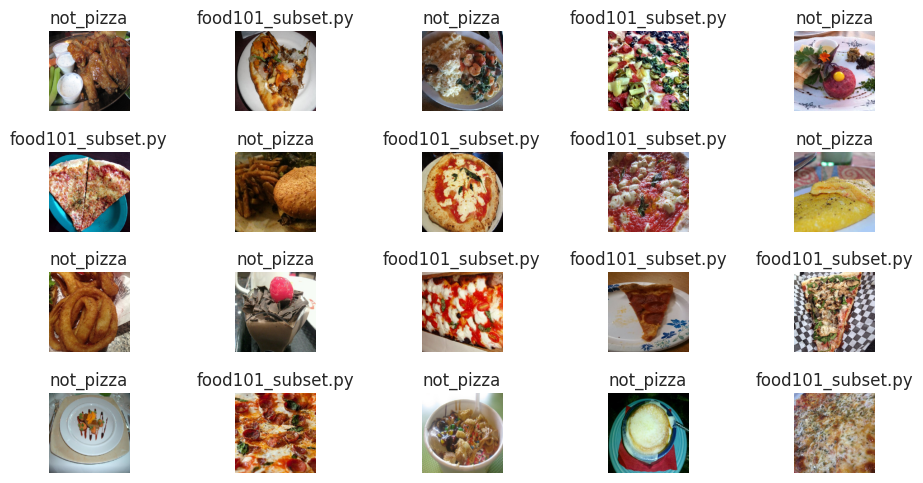

In [29]:
plot_random_images()

### 3. Baseline model
Let Us First create a baseline model without doing data augmentation and not adding a Max Pooling Layer

In [30]:
tf.random.set_seed(42)

model_1 = Sequential([
    Input(shape = (224, 224, 3)), # Input layer
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'), # First C
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'), # Second
    Flatten(),
    Dense(1, activation = 'sigmoid') # Output layer
])
model_1.compile(loss = BinaryCrossentropy(),
                optimizer = Adam(),
                metrics = ['accuracy'])

history_1 = model_1.fit(train_data,
                        epochs= 5,
                        steps_per_epoch = len(train_data),
                        validation_data = val_data,
                        validation_steps = len(val_data))


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.5127 - loss: 2.0386 - val_accuracy: 0.5153 - val_loss: 0.6871
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.6588 - loss: 0.6380 - val_accuracy: 0.6148 - val_loss: 0.6558
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.8297 - loss: 0.4310 - val_accuracy: 0.6148 - val_loss: 0.7225
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.9479 - loss: 0.1714 - val_accuracy: 0.7066 - val_loss: 0.6012
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.9905 - loss: 0.0575 - val_accuracy: 0.6480 - val_loss: 0.8696


### 4. Visualizing the Results

In [31]:
# Plot the validation and training data separately
def plot_loss_curves(history):
    """
    Plots the curves of both loss and accuracy
    """

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    epochs = range(len(loss))

    fig, ax = plt.subplots(1, 2, figsize = (20, 5))

    # Plotting loss
    ax1 = sns.lineplot(x = epochs, y = loss, label='Training Loss', ax= ax[0])
    ax1 = sns.lineplot(x = epochs, y = val_loss, label='Validation Loss', ax= ax[0])
    ax1.set(title = 'Loss', xlabel = 'Epochs')
    
    # Plot accuracy
    ax2 = sns.lineplot(x = epochs, y = accuracy, label='Training Accuracy', ax= ax[1])
    ax2 = sns.lineplot(x = epochs, y = val_accuracy, label='Validation Accuracy', ax=ax[1])
    ax2.set(title = 'Accuracy', xlabel = 'Epochs')


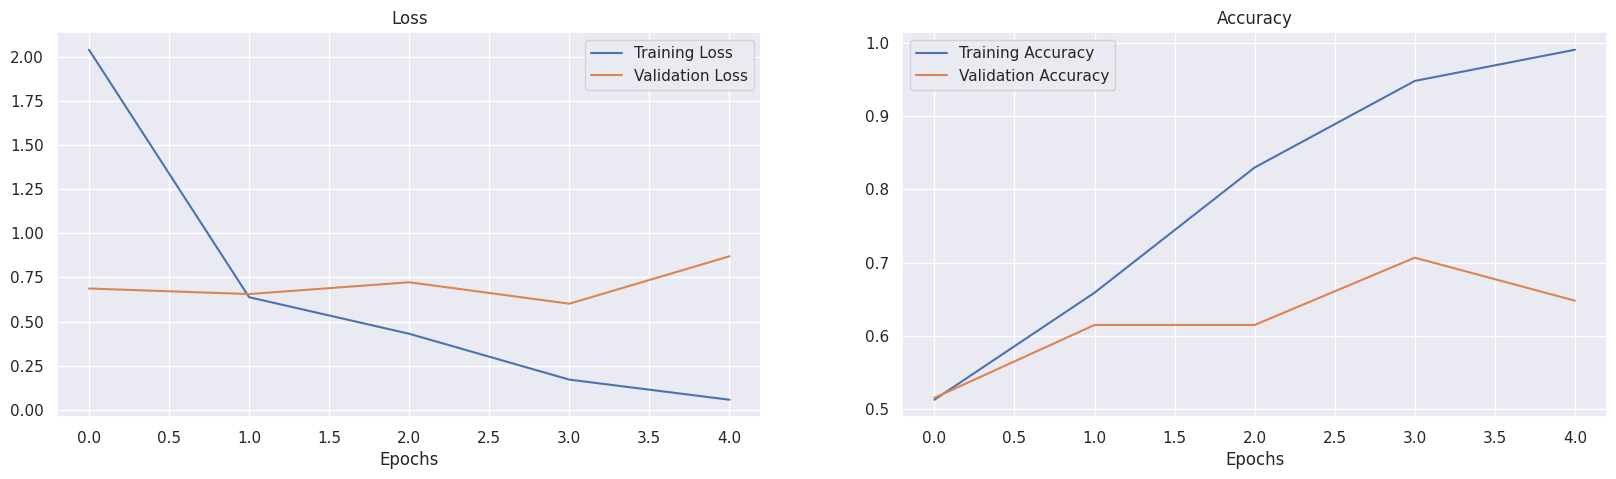

In [32]:
plot_loss_curves(history_1)

### 5. Adding a Max Pooling Layer
Lets add a Max Pooling layer and check whether the accuracy improves

In [33]:
model_2 = Sequential([
    Input(shape = (224, 224, 3)),
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2), # It will reduce the number of features by half
    Conv2D(filters = 32, kernel_size =2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Flatten(),
    Dense(1, activation = 'sigmoid')
])
model_2.compile(
    loss = BinaryCrossentropy(),
    optimizer = Adam(),
    metrics = ['accuracy'])

history_2 = model_2.fit(
    train_data,
    epochs= 5,
    steps_per_epoch = len(train_data),
    validation_data = val_data,
    validation_steps = len(val_data))

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.5813 - loss: 0.7579 - val_accuracy: 0.6939 - val_loss: 0.6097
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.6881 - loss: 0.5891 - val_accuracy: 0.7500 - val_loss: 0.5664
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7605 - loss: 0.5197 - val_accuracy: 0.6913 - val_loss: 0.5539
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8291 - loss: 0.4307 - val_accuracy: 0.7474 - val_loss: 0.5300
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8647 - loss: 0.3556 - val_accuracy: 0.7219 - val_loss: 0.5443


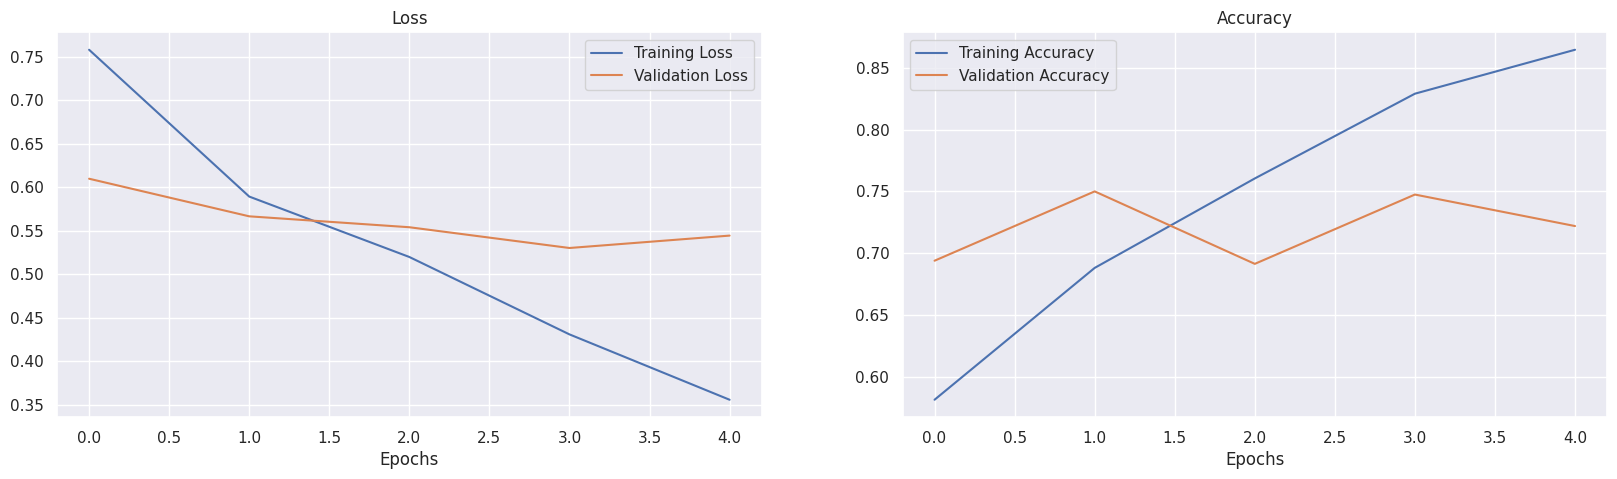

In [34]:
plot_loss_curves(history_2)

We have a maximum validation accuracy of around 75% which is an improvement as compared to our previous model, let
us do data augmentation and see whether it improves the accuracy further

### 6. Data Augmentation

In [35]:
data_gen_augmented = ImageDataGenerator(
    rescale = 1/255.,
    validation_split = 0.2,
    zoom_range = 0.2,
    horizontal_flip= True,
    rotation_range = 20,
    width_shift_range=0.2,
    height_shift_range=0.2)

print('Augmented training Images:')
train_data_augmented = data_gen_augmented.flow_from_directory(
    data_directory,
    target_size = (224, 224),
    batch_size = 32,
    subset = 'training',
    class_mode = 'binary')

print('Unchanged Validation Images:')
val_data = data_gen.flow_from_directory(
    data_directory,
    target_size = (224, 224),
    batch_size = 32,
    subset = 'validation',
    class_mode = 'binary')

Augmented training Images:
Found 1574 images belonging to 2 classes.
Unchanged Validation Images:
Found 392 images belonging to 2 classes.


In [36]:
def plot_random_images_augmented():
    """
    Plots 20 Random Images from the dataset
    """
    
    images_augmented, labels_augmented = next(train_data_augmented)
    labels_augmented = labels_augmented.astype('int32')
    i = 1
    plt.figure(figsize = (10, 5))

    for image, label in zip(images_augmented, labels_augmented):
        plt.subplot(4, 5, i)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis('off')
        i += 1
        if i == 21:
            break

    plt.tight_layout()
    plt.show()

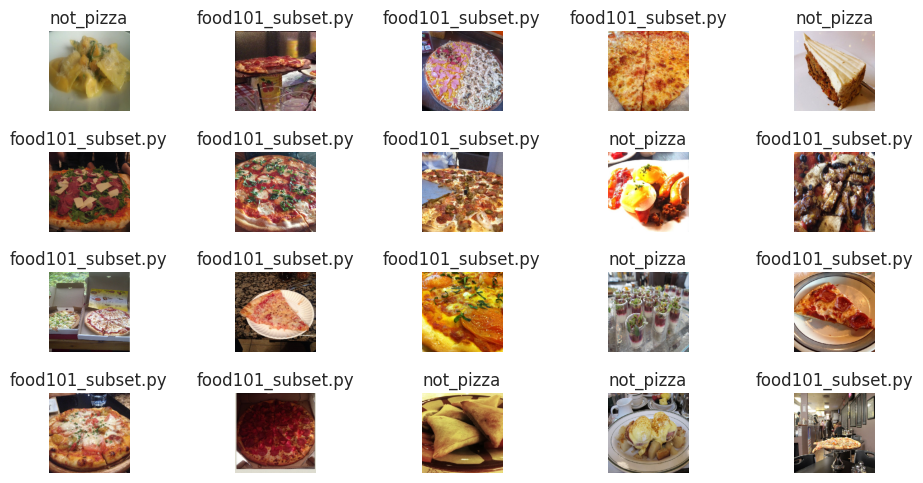

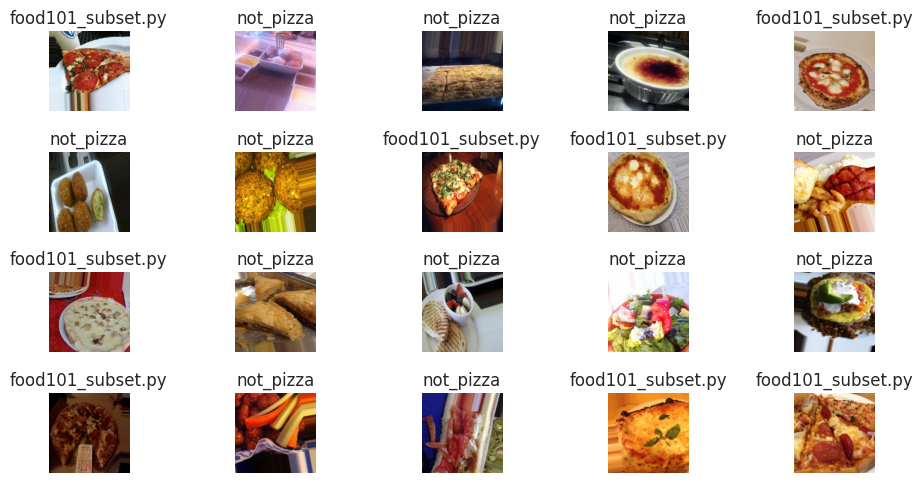

In [37]:
plot_random_images()
print('==================================================================================================')
plot_random_images_augmented()

In [38]:
model_3 = Sequential([
    Input(shape = (224, 224, 3)),
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Flatten(),
    Dense(1, activation = 'sigmoid')
    ])

model_3.compile(
    loss = BinaryCrossentropy(),
    optimizer = Adam(),
    metrics = ['accuracy'])

history_3 = model_3.fit(
    train_data_augmented, # changing the training data
    epochs= 5,
    steps_per_epoch = len(train_data_augmented),
    validation_data = val_data,
    validation_steps = len(val_data))

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 248ms/step - accuracy: 0.6017 - loss: 0.6701 - val_accuracy: 0.6403 - val_loss: 0.6256
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 226ms/step - accuracy: 0.6137 - loss: 0.6520 - val_accuracy: 0.7168 - val_loss: 0.5911
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 221ms/step - accuracy: 0.6595 - loss: 0.6171 - val_accuracy: 0.7500 - val_loss: 0.5612
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 224ms/step - accuracy: 0.6976 - loss: 0.5897 - val_accuracy: 0.7806 - val_loss: 0.5305
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 224ms/step - accuracy: 0.7078 - loss: 0.5771 - val_accuracy: 0.6709 - val_loss: 0.6075


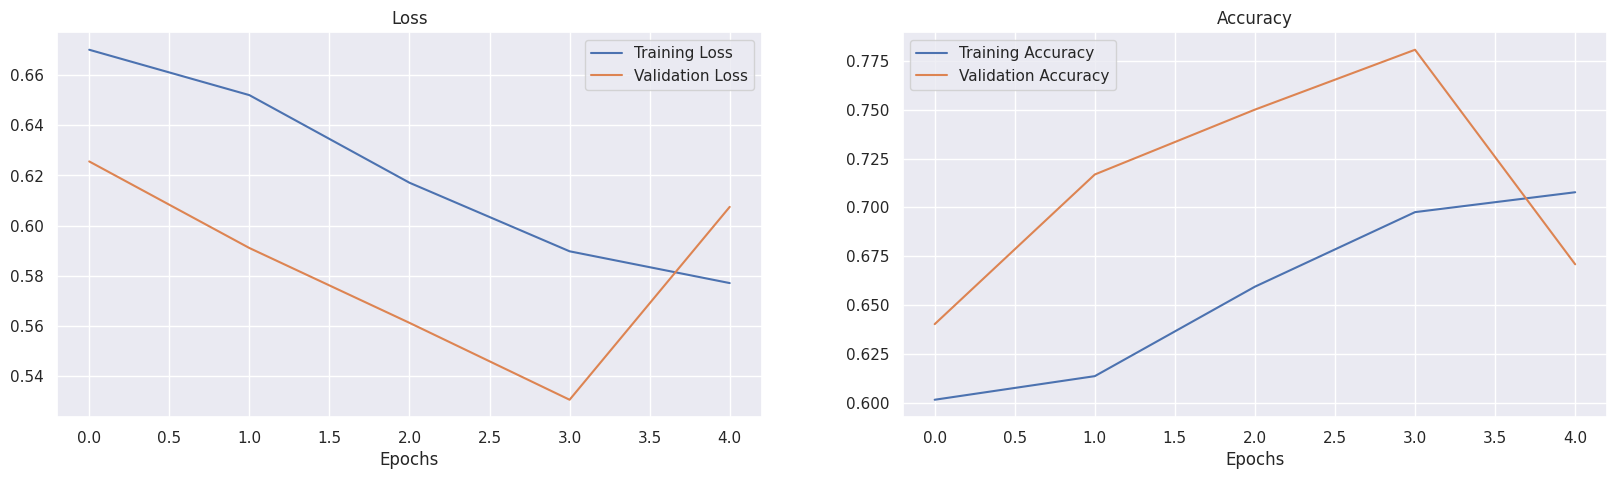

In [39]:
plot_loss_curves(history_3)

We did reach a maximum accuracy of above 70%, we can certainly make some more changes and try to improve the
accuracy further

### 7. Improving the model

There are lot of things we can change for improving the model such as:
1. Increasing the number of epochs
2. Adding more convolutional layers
3. Changing the number of filters
4. Changing the size of our filters
5. Changing the pool size of Max Pooling layer


In [40]:
model_4 = Sequential([
    Input(shape = (224, 224, 3)),
    Conv2D(filters = 10, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Conv2D(filters = 64, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Flatten(),
    Dense(1, activation = 'sigmoid')
])

model_4.compile(
    loss = BinaryCrossentropy(),
    optimizer = Adam(learning_rate = 0.0001),
    metrics = ['accuracy'])

history_4 = model_4.fit(
    train_data, # Using non-augmented data
    epochs= 20,
    steps_per_epoch = len(train_data),
    validation_data = val_data,
    validation_steps = len(val_data))


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.5426 - loss: 0.6871 - val_accuracy: 0.5306 - val_loss: 0.6733
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.6404 - loss: 0.6639 - val_accuracy: 0.7296 - val_loss: 0.6408
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.6493 - loss: 0.6399 - val_accuracy: 0.7066 - val_loss: 0.6155
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7173 - loss: 0.6028 - val_accuracy: 0.7168 - val_loss: 0.5854
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6970 - loss: 0.5831 - val_accuracy: 0.7372 - val_loss: 0.5672
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.7382 - loss: 0.5590 - val_accuracy: 0.7270 - val_loss: 0.5499
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.7421 - loss: 0.5465 - val_accuracy: 0.7602 - val_loss: 0.5398
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.7586 - loss: 0.5238 - val_accuracy: 0.7321 -

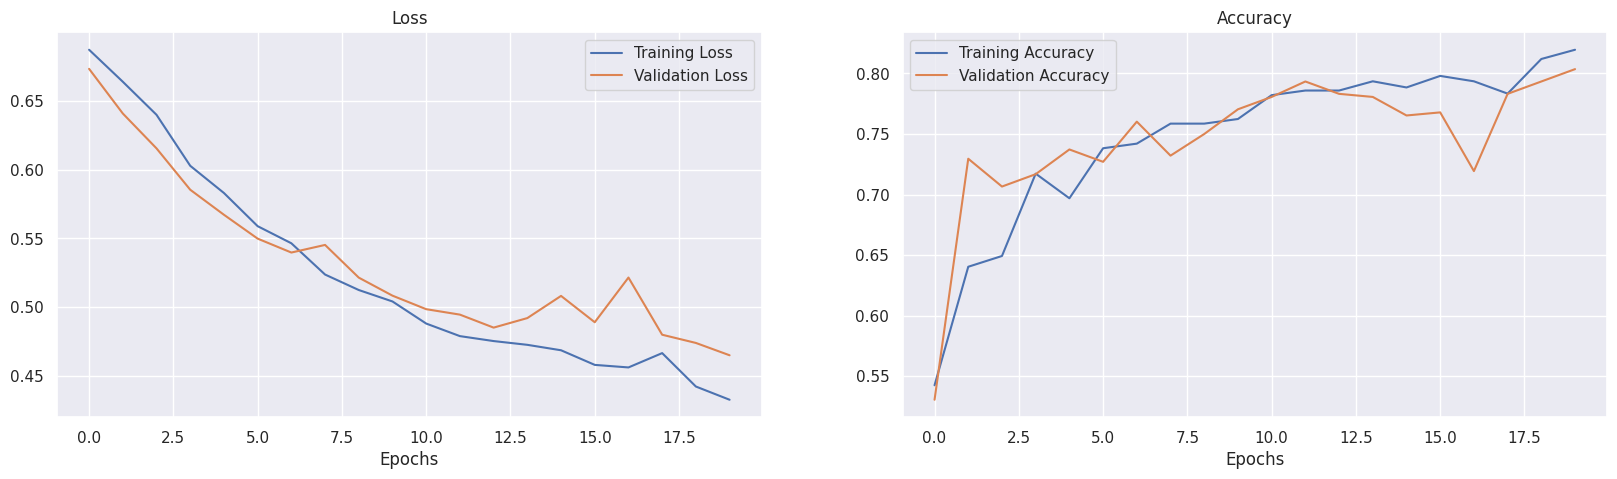

In [41]:
plot_loss_curves(history_4)

So we did managed to improve our accuracy to around 80%, which I think is not that bad considering the amount of
images we had.

### 8. Transfer Learning

In [42]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

#EfficientNet langsung
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False

# Model
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_5 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20


E0000 00:00:1776255009.626850   19442 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_8_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 227ms/step - accuracy: 0.5076 - loss: 0.7628 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - accuracy: 0.5140 - loss: 0.7359 - val_accuracy: 0.5281 - val_loss: 0.6930
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - accuracy: 0.5121 - loss: 0.7375 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - accuracy: 0.5102 - loss: 0.7228 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - accuracy: 0.5121 - loss: 0.7323 - val_accuracy: 0.4974 - val_loss: 0.6931
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - accuracy: 0.5184 - loss: 0.7224 - val_accuracy: 0.5485 - val_loss: 0.6927
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - accuracy: 0.4809 - loss: 0.7301 - val_accuracy: 0.5102 - val_loss: 0.6930
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - accuracy: 0.4943 - loss: 0.7240 - val_accuracy: 0.4949 - val

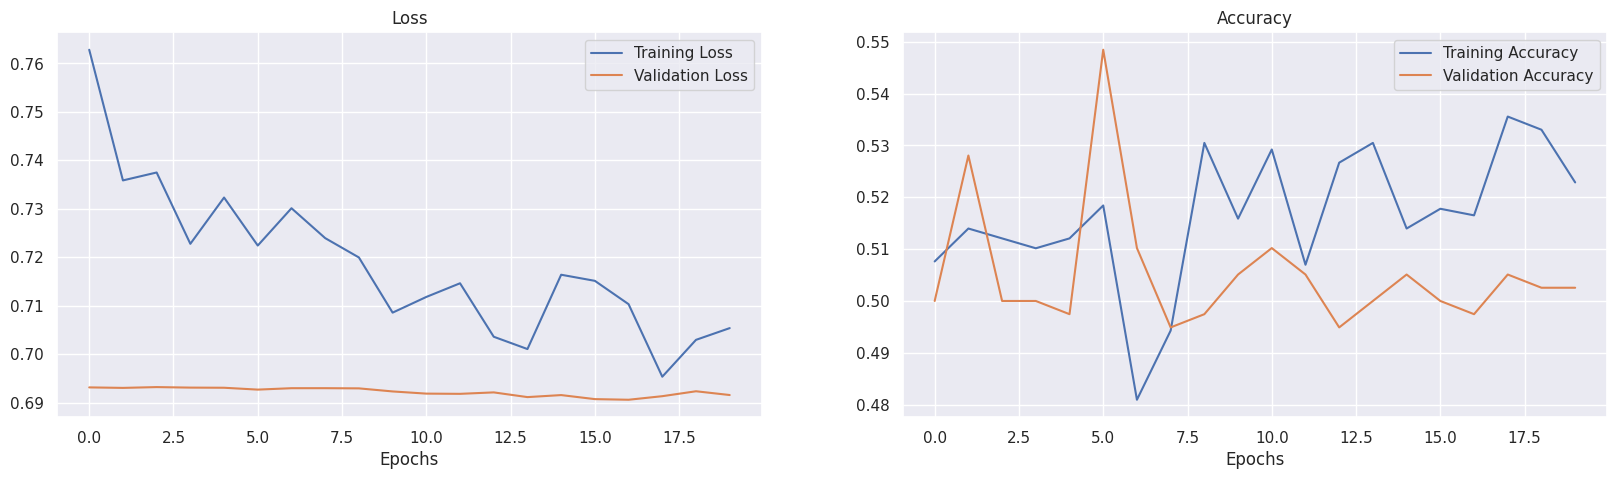

In [43]:
plot_loss_curves(history_5)